In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (225745, 79)

Columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', 

In [2]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

print("Label Distribution:")
print(df['Label'].value_counts())
print("\nLabel Percentages:")
print(df['Label'].value_counts(normalize=True).round(4) * 100)

Label Distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Label Percentages:
Label
DDoS      56.71
BENIGN    43.29
Name: proportion, dtype: float64


In [3]:
print("Missing Values:")
print(df.isnull().sum().sum(), "total missing values")

print("\nInfinite Values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum(), "total infinite values")

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nBasic Stats for key features:")
df[['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'SYN Flag Count']].describe()

Missing Values:
4 total missing values

Infinite Values:
64 total infinite values

Data Types:
int64      54
float64    24
object      1
Name: count, dtype: int64

Basic Stats for key features:


,Flow Duration,Flow Bytes/s,Flow Packets/s,SYN Flag Count
count,2.257450e+05,2.257410e+05,2.257450e+05,225745.000000
mean,1.624165e+07,inf,inf,0.033223
std,3.152437e+07,NaN,NaN,0.179220
min,-1.000000e+00,-1.200000e+07,-2.000000e+06,0.000000
25%,7.118000e+04,1.209087e+01,6.185506e-01,0.000000
50%,1.452333e+06,1.136606e+03,5.179323e+00,0.000000
75%,8.805237e+06,2.159723e+04,7.046933e+01,0.000000
max,1.199999e+08,inf,inf,1.000000


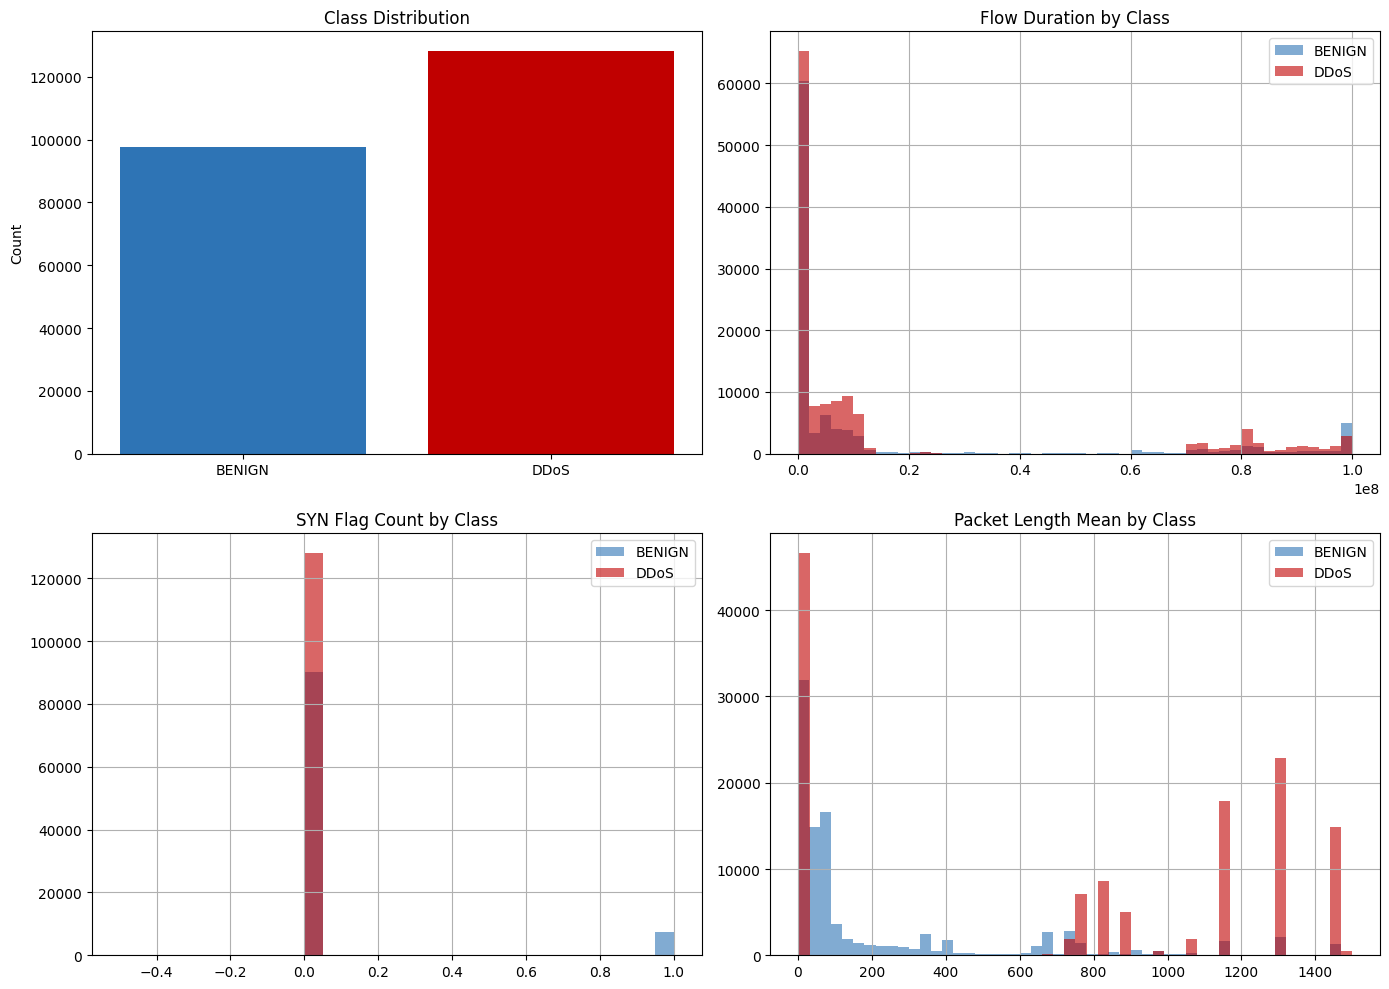

Saved!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Class distribution
axes[0,0].bar(['BENIGN', 'DDoS'], 
              [len(df[df['Label']=='BENIGN']), len(df[df['Label']=='DDoS'])],
              color=['#2E74B5', '#C00000'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')

# Flow Duration by class
df[df['Label']=='BENIGN']['Flow Duration'].clip(0, 1e8).hist(
    ax=axes[0,1], bins=50, alpha=0.6, label='BENIGN', color='#2E74B5')
df[df['Label']=='DDoS']['Flow Duration'].clip(0, 1e8).hist(
    ax=axes[0,1], bins=50, alpha=0.6, label='DDoS', color='#C00000')
axes[0,1].set_title('Flow Duration by Class')
axes[0,1].legend()

# SYN Flag Count by class
df[df['Label']=='BENIGN']['SYN Flag Count'].hist(
    ax=axes[1,0], bins=20, alpha=0.6, label='BENIGN', color='#2E74B5')
df[df['Label']=='DDoS']['SYN Flag Count'].hist(
    ax=axes[1,0], bins=20, alpha=0.6, label='DDoS', color='#C00000')
axes[1,0].set_title('SYN Flag Count by Class')
axes[1,0].legend()

# Packet Length Mean by class
df[df['Label']=='BENIGN']['Packet Length Mean'].clip(0, 1500).hist(
    ax=axes[1,1], bins=50, alpha=0.6, label='BENIGN', color='#2E74B5')
df[df['Label']=='DDoS']['Packet Length Mean'].clip(0, 1500).hist(
    ax=axes[1,1], bins=50, alpha=0.6, label='DDoS', color='#C00000')
axes[1,1].set_title('Packet Length Mean by Class')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../data/siem_eda.png')
plt.show()
print("Saved!")

In [5]:
print("=" * 55)
print("SIEM ANOMALY DETECTOR — RESEARCH SUMMARY")
print("=" * 55)
print(f"\nDataset: CICIDS 2017 — Friday DDoS")
print(f"Total records: {len(df):,}")
print(f"Features: {df.shape[1] - 1} (excluding Label)")
print(f"\nClass Distribution:")
print(f"  BENIGN: {len(df[df['Label']=='BENIGN']):,} ({43.29}%)")
print(f"  DDoS:   {len(df[df['Label']=='DDoS']):,} ({56.71}%)")
print(f"\nData Quality Issues:")
print(f"  Missing values: 4")
print(f"  Infinite values: 64")
print(f"  Negative Flow Duration: needs filtering")
print(f"\nModel Plan:")
print(f"  Algorithm: Isolation Forest (unsupervised)")
print(f"  Approach: Train on BENIGN only, flag deviations")
print(f"  Features: Selected subset of 78 numeric features")
print(f"  Framework: scikit-learn")
print("=" * 55)
print("Research complete. Ready to train.")

SIEM ANOMALY DETECTOR — RESEARCH SUMMARY

Dataset: CICIDS 2017 — Friday DDoS
Total records: 225,745
Features: 78 (excluding Label)

Class Distribution:
  BENIGN: 97,718 (43.29%)
  DDoS:   128,027 (56.71%)

Data Quality Issues:
  Missing values: 4
  Infinite values: 64
  Negative Flow Duration: needs filtering

Model Plan:
  Algorithm: Isolation Forest (unsupervised)
  Approach: Train on BENIGN only, flag deviations
  Features: Selected subset of 78 numeric features
  Framework: scikit-learn
Research complete. Ready to train.
